In [11]:
from neo4j import GraphDatabase
import networkx as nx
import getpass
from neo4j.exceptions import AuthError, ServiceUnavailable

# ================== 1. Kết nối Neo4j ==================
uri = "bolt://localhost:7687"
user = "neo4j"
# Nhập mật khẩu an toàn (không lưu trong notebook)
password = getpass.getpass("Neo4j password for user 'neo4j': ")

# Tạo driver và kiểm tra kết nối / xác thực để hiển thị lỗi rõ ràng nếu có
try:
    driver = GraphDatabase.driver(uri, auth=(user, password))
    # test kết nối nhanh
    with driver.session() as session:
        session.run("RETURN 1")
except AuthError as e:
    raise RuntimeError("Authentication failed: check your Neo4j username/password.") from e
except ServiceUnavailable as e:
    raise RuntimeError(f"Cannot connect to Neo4j at {uri}: is the database running?") from e

# ================== 2. Lấy tất cả node ==================
with driver.session() as session:
    query_nodes = """
    MATCH (n)
    WHERE n: Singer OR n: Band OR n: Genre OR n: Label
    RETURN elementId(n) AS id, labels(n) AS labels, n.name AS name
    """
    nodes_result = session.run(query_nodes)
    node_info = {str(record["id"]): {"name": record["name"], "labels": record["labels"]}
                 for record in nodes_result}

print("Total nodes:", len(node_info))

# ================== 3. Lấy tất cả quan hệ ==================
with driver.session() as session:
    query_edges = """
    MATCH (a)-[r]->(b)
    WHERE elementId(a) < elementId(b)
    RETURN elementId(a) AS source, elementId(b) AS target
    """
    edges_result = session.run(query_edges)
    edges = [(str(record["source"]), str(record["target"])) for record in edges_result]

print("Total edges:", len(edges))

# ================== 4. Tạo graph NetworkX ==================
G = nx.Graph()
G.add_nodes_from(node_info.keys())
G.add_edges_from(edges)

print("Graph created. Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())


Total nodes: 1581
Total edges: 10789
Graph created. Nodes: 1708 Edges: 10789


In [5]:
with driver.session() as session:
    query_edges = """
    MATCH (a:Singer)-[r]->(b:Singer)
    WHERE type(r) IN ['COLLABORATED_WITH','MEMBER_OF'] AND elementId(a) < elementId(b)
    RETURN elementId(a) AS source, elementId(b) AS target
    """
    edges_result = session.run(query_edges)
    edges = [(record["source"], record["target"]) for record in edges_result]

print("Total edges:", len(edges))

# ================== 3. Tạo NetworkX Graph ==================
G = nx.Graph()
G.add_edges_from(edges)

# ================== 4. Tính Average Shortest Path Length ==================
if nx.is_connected(G):
    aspl = nx.average_shortest_path_length(G)
else:
    # Nếu graph không liên thông hoàn toàn, dùng largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    aspl = nx.average_shortest_path_length(G_sub)

print("Average Shortest Path Length (ASPL):", aspl)

Total edges: 9204
Average Shortest Path Length (ASPL): 2.9153419692493956


In [13]:
# ================== PageRank ==================
pr = nx.pagerank(G)

# Hàm lọc top n theo label (bỏ qua node không có trong node_info để tránh KeyError)
def top_n_by_label(pr_dict, node_info_dict, label, n=10):
    filtered = {}
    for node_id, score in pr_dict.items():
        info = node_info_dict.get(node_id)
        if not info:
            # nếu không có thông tin node trong node_info, bỏ qua
            continue
        labels = info.get("labels") or []
        # đảm bảo labels là iterable; kiểm tra membership
        if label in labels:
            filtered[node_id] = score
    top_n = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:n]
    # trả về tên nếu có, ngược lại trả về node_id làm fallback
    return [(node_info_dict.get(node_id, {}).get("name", node_id), score) for node_id, score in top_n]

# Top 10 theo từng loại node
top_10_singers = top_n_by_label(pr, node_info, "Singer")
top_10_bands = top_n_by_label(pr, node_info, "Band")
top_10_genres = top_n_by_label(pr, node_info, "Genre")
top_10_labels = top_n_by_label(pr, node_info, "Label")

# In kết quả
print("Top 10 Singers by PageRank:")
for name, score in top_10_singers:
    print(name, score)

print("\nTop 10 Bands by PageRank:")
for name, score in top_10_bands:
    print(name, score)

print("\nTop 10 Genres by PageRank:")
for name, score in top_10_genres:
    print(name, score)

print("\nTop 10 Labels by PageRank:")
for name, score in top_10_labels:
    print(name, score)


Top 10 Singers by PageRank:
Đàm Vĩnh Hưng 0.004633999129596532
Mỹ Tâm 0.004547355541526413
Vũ Cát Tường 0.004468718242715355
Tùng Dương 0.0043662195343136135
Phạm Duy 0.004362671603465198
Trịnh Công Sơn 0.004072750277671391
Đức Trí 0.004050272564336046
Hứa Kim Tuyền 0.0040406901062951224
Trần Thu Hà 0.003817972605156087
Giáng Son 0.003816521402689666

Top 10 Bands by PageRank:
Bức Tường 0.0003273732908440535
1088 0.0002744875155578295
Trịnh Lâm Ngân 0.00023001422808241733
Mây Trắng 0.00022678831626194216
Lê Minh Bằng 0.00021763527968450612
H.A.T 0.00020074810605381593
5 Dòng Kẻ 0.000188397060415014
365daband 0.0001827168356058209
Phượng Hoàng 0.00017960332642772239
Monstar 0.00017824048858481584

Top 10 Genres by PageRank:
V-pop 0.0039706025884670045
Nhạc vàng 0.003638105057326026
R&B 0.0030893305982744733
Nhạc trẻ 0.003066006494821463
Pop 0.0024619996296520864
ballad 0.0022500036422597133
Tình khúc 1954–1975 0.002226373712210291
Nhạc trữ tình 0.001837080326542578
dance-pop 0.001555231

Total communities detected: 416
Community sizes: Counter({18: 392, 15: 320, 26: 287, 42: 122, 14: 85, 29: 67, 24: 12, 265: 6, 25: 5, 27: 3, 8: 2, 30: 2, 262: 2, 0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 6: 1, 7: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 16: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 28: 1, 31: 1, 32: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 1, 128: 1, 129: 1, 130: 1, 131:

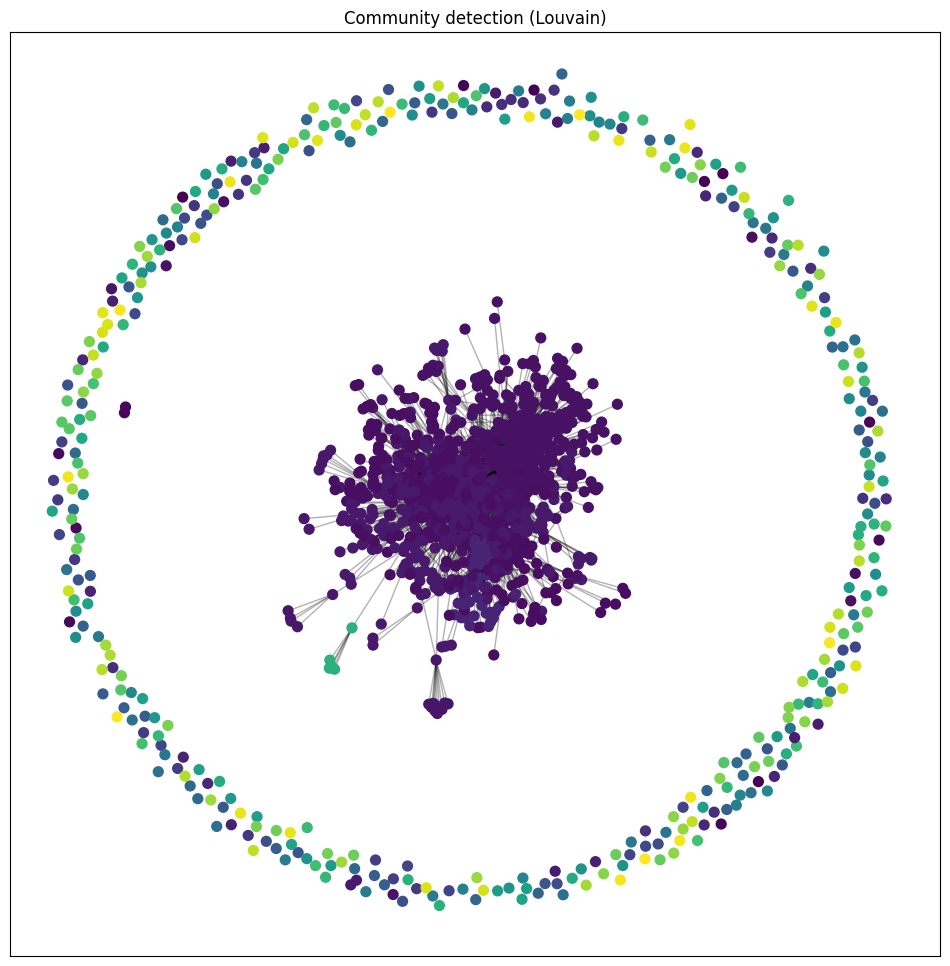

In [15]:
# Cài đặt nếu chưa có
# pip install python-louvain

import community as community_louvain
import matplotlib.pyplot as plt

# --- 1. Tính cộng đồng ---
# Trả về dictionary node_id -> community_id
partition = community_louvain.best_partition(G)

# --- 2. Thống kê số lượng cộng đồng và kích thước mỗi cộng đồng ---
from collections import Counter
community_sizes = Counter(partition.values())
print(f"Total communities detected: {len(community_sizes)}")
print("Community sizes:", community_sizes)

# --- 3. Thêm màu cho visualization nếu muốn ---
size = float(len(set(partition.values())))
pos = nx.spring_layout(G)  # layout cho đồ thị
cmap = plt.get_cmap('viridis', len(community_sizes))

plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G, pos, partition.keys(), node_size=50,
                       cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title("Community detection (Louvain)")
plt.show()


In [16]:
# ================== Phát hiện cộng đồng ==================
import networkx as nx
from collections import Counter
import pandas as pd
import community as community_louvain  # Louvain

# --- 1. Lấy cạnh quan hệ ý nghĩa ---
query = """
MATCH (a:Singer)-[r:COLLABORATED_WITH|MEMBER_OF]-(b)
WHERE elementId(a) < elementId(b)
RETURN elementId(a) AS source, elementId(b) AS target
"""

with driver.session() as session:
    results = session.run(query)
    edges = [(record["source"], record["target"]) for record in results]

# --- 2. Tạo graph ---
G = nx.Graph()
G.add_edges_from(edges)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

# --- 3. Lấy largest connected component nếu graph rời rạc ---
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
    print("Largest connected component nodes:", G.number_of_nodes())

# --- 4. Chạy Louvain để phát hiện cộng đồng ---
partition = community_louvain.best_partition(G)

# --- 5. Thống kê kích thước cộng đồng ---
community_sizes = Counter(partition.values())
print("Total communities detected:", len(community_sizes))
print("Top 10 largest communities:", community_sizes.most_common(10))

# --- 6. Lọc cộng đồng lớn (>=10 nodes) ---
large_communities = {cid: size for cid, size in community_sizes.items() if size >= 10}

# --- 7. Tạo DataFrame node theo cộng đồng ---
nodes_by_community = {}
for node, cid in partition.items():
    if cid in large_communities:
        nodes_by_community.setdefault(cid, []).append(node)

# Lấy thông tin node name + community
rows = []
for cid, nodes in nodes_by_community.items():
    for node in nodes:
        # Lấy tên node từ node_info nếu đã có, hoặc node id
        name = node_info[node]["name"] if node in node_info else str(node)
        labels = node_info[node]["labels"] if node in node_info else []
        rows.append({"node_id": node, "name": name, "labels": labels, "community_id": cid})

df_communities = pd.DataFrame(rows)
print(df_communities.head(20))

# --- 8. Thống kê nhãn trong mỗi cộng đồng ---
community_summary = df_communities.groupby("community_id")["labels"].apply(list)
print(community_summary.head(10))


Nodes: 736 Edges: 9227
Total communities detected: 4
Top 10 largest communities: [(0, 263), (3, 254), (1, 123), (2, 96)]
                                       node_id               name    labels  \
0   4:25a89893-5700-4f3c-81cd-0dc1be9d0b5e:702           Lệ Quyên  [Singer]   
1   4:25a89893-5700-4f3c-81cd-0dc1be9d0b5e:748         Minh Tuyết  [Singer]   
2   4:25a89893-5700-4f3c-81cd-0dc1be9d0b5e:760   Trần Thiện Thanh  [Singer]   
3   4:25a89893-5700-4f3c-81cd-0dc1be9d0b5e:767          Mạnh Phát  [Singer]   
4   4:25a89893-5700-4f3c-81cd-0dc1be9d0b5e:773              Ý Lan  [Singer]   
5   4:25a89893-5700-4f3c-81cd-0dc1be9d0b5e:794           Hồng Vân  [Singer]   
6   4:25a89893-5700-4f3c-81cd-0dc1be9d0b5e:802          Như Quỳnh  [Singer]   
7   4:25a89893-5700-4f3c-81cd-0dc1be9d0b5e:807    Phạm Mạnh Cương  [Singer]   
8   4:25a89893-5700-4f3c-81cd-0dc1be9d0b5e:969            Minh Kỳ  [Singer]   
9   4:25a89893-5700-4f3c-81cd-0dc1be9d0b5e:912             Lệ Thu  [Singer]   
10  4:25a8

In [19]:
# ================== Community Analysis ==================
import pandas as pd
from collections import Counter

# Giả sử df_nodes có các cột: node_id, name, labels, community_id, genre, activeYears, pagerank
# Nếu chưa có pagerank, có thể thêm từ dict pr: df_nodes['pagerank'] = df_nodes['node_id'].map(pr)

# 1. Tạo summary theo cộng đồng
community_summary = []

for cid in sorted(df_nodes['community_id'].unique()):
    community_nodes = df_nodes[df_nodes['community_id'] == cid]
    
    # Thống kê dòng nhạc phổ biến
    genres = community_nodes['genre'].dropna()
    top_genres = [g for g, _ in Counter(genres).most_common(3)]
    
    # Thống kê activeYears / thập niên phổ biến
    years = community_nodes['activeYears'].dropna()
    top_years = [y for y, _ in Counter(years).most_common(3)]
    
    # Top 10 ca sĩ/band theo pagerank
    if 'pagerank' in community_nodes.columns:
        top_nodes = community_nodes.sort_values(by='pagerank', ascending=False).head(10)
    else:
        top_nodes = community_nodes.head(10)  # nếu chưa có pagerank, lấy top theo thứ tự hiện tại
    
    top_names = top_nodes['name'].tolist()
    
    # Lưu thông tin
    community_summary.append({
        'community_id': cid,
        'num_nodes': len(community_nodes),
        'top_genres': top_genres,
        'top_years': top_years,
        'top_names': top_names
    })

# 2. Chuyển sang DataFrame để hiển thị
df_community_summary = pd.DataFrame(community_summary)

# 3. Hiển thị kết quả
pd.set_option('display.max_colwidth', None)
print("Community Summary:")
df_community_summary


Community Summary:


,community_id,num_nodes,top_genres,top_years,top_names
0,0,263,[],[],"[Phạm Duy, Phi Nhung, Thanh Tuyền, Hương Lan, Duy Khánh, Y Vân, Lệ Quyên, Cẩm Ly, Phượng Mai, Văn Cao]"
1,1,123,[],[],"[Đàm Vĩnh Hưng, Mỹ Tâm, Tùng Dương, Trịnh Công Sơn, Đức Trí, Trần Thu Hà, Giáng Son, Mỹ Linh, Thanh Lam, Thu Phương]"
2,2,96,[],[],"[Trần Mạnh Hùng, Trần Tiến, Nguyễn Cường, Hội Nhạc sĩ Việt Nam, Phó Đức Phương, Duy Thái, Nguyễn Thị Nhung, Nguyễn Ngọc Thiện, Trọng Đài, Vũ Tự Lân]"
3,3,254,[],[],"[Vũ Cát Tường, Hứa Kim Tuyền, Sơn Tùng M-TP, Hoài Lâm, Hồ Ngọc Hà, Ngô Kiến Huy, Florian Picasso, Noo Phước Thịnh, Đan Trường, Trúc Nhân]"
